In [21]:
import requests # Importerar 'requests' biblioteket för att göra HTTP-förfrågningar till webben.
import json # Importerar 'json' biblioteket för att hantera JSON-data.
import pandas as pd # Importerar 'pandas' biblioteket för dataanalys och manipulation, alias 'pd'.
from pathlib import Path # Importerar 'Path' från 'pathlib' för att hantera filvägar på ett plattformsoberoende sätt.
from sklearn.preprocessing import MinMaxScaler # Importerar MinMaxScaler för att skala data för normalizeringen inför ML/AI-träning.

# ===========================================================================
# KLASSDEFINITIONER
# Dessa klasser används för att representera datapunkter på ett strukturerat sätt.
# ===========================================================================
class DataPoint:
    """En generell föräldraklass för en datapunkt med grundläggande information."""
    def __init__(self, timestamp, price): # konstruktor
        self.timestamp = timestamp # Datum och tid för datapunkten.
        self.price = price         # Priset vid den angivna tidpunkten.

    def display_basic_info(self):
        """Returnerar en sträng med grundläggande information om datapunkten."""
        return f"Tid: {self.timestamp.strftime('%Y-%m-%d')}, Pris: {self.price:.2f} USD"

class BitcoinDataPoint(DataPoint):
    """En barnklass för en Bitcoin-datapunkt, ärver från DataPoint och lägger till specifika Bitcoin-mått."""
    def __init__(self, timestamp, price, ma20, ma50, volatility):
        super().__init__(timestamp, price)  # Anropar föräldraklassens konstruktor för att initialisera timestamp och price.
        self.ma20 = ma20                   # 20-perioders glidande medelvärde (Moving Average).
        self.ma50 = ma50                   # 50-perioders glidande medelvärde.
        self.volatility = volatility       # Volatilitet för datapunkten.

    def display_detailed_info(self):
        """Returnerar en sträng med detaljerad information inklusive Bitcoin-specifika mått."""
        basic_info = self.display_basic_info() # Använder display_basic_info() från föräldraklassen.
        return (
            f"{basic_info}, MA20: {self.ma20:.2f}, MA50: {self.ma50:.2f}, Volatilitet: {self.volatility:.4f}"
        )

# ===========================================================================
# INSTÄLLNINGAR OCH FILHANTERING
# Konfigurerar API-anrop och definierar sökvägar för datalagring.
# ===========================================================================
API_URL = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart" # Bas-URL för CoinGecko API för Bitcoin-marknadsdata.
PARAMS = { # Parametrar som skickas med API-förfrågan för att specificera vilken data som önskas.
    "vs_currency": "usd", # Anger att priset ska hämtas i USD (US-dollar).
    "days": "365"       # Anger att data ska hämtas för de senaste 365 dagarna (ungefär 1 år).
}
DATA_FOLDER = Path("data") # Definierar sökvägen till mappen där datafiler ska sparas.
RAW_FILE = DATA_FOLDER / "bitcoin_raw.json" # Fullständig sökväg för att spara rådata i JSON-format.
PROCESSED_FILE = DATA_FOLDER / "bitcoin_processed.csv" # Fullständig sökväg för att spara bearbetad och normaliserad data i CSV-format.

# Skapar 'data'-mappen om den inte redan existerar för att undvika fel vid filskrivning.
DATA_FOLDER.mkdir(exist_ok=True)

# ===========================================================================
# 1. HÄMTA DATA FRÅN COINGECKO VIA API MED FELHANTERING
# Anropar CoinGecko API för att få den senaste Bitcoin-marknadsdatan.
# ===========================================================================
print("Hämtar Bitcoin-data från CoinGecko...") # Användarmeddelande.
try:
    # Gör en GET-förfrågan till API:et med angivna parametrar och en timeout på 30 sekunder.
    response = requests.get(API_URL, params=PARAMS, timeout=30)
    # Kontrollerar HTTP-statuskoden för att se om API-anropet lyckades (200 OK).
    response.raise_for_status() # Kommer att utlösa ett HTTPError för dåliga svar (4xx eller 5xx).
    data = response.json() # Parsar JSON-svaret till ett Python dictionary.
    print("Data hämtad!") # Bekräftelsemeddelande.
except requests.exceptions.RequestException as e:
    print(f"Ett fel uppstod vid hämtning av data från CoinGecko: {e}") # Felmeddelande vid misslyckad förfrågan.
    print("Kontrollera din internetanslutning eller API-URL:en.")
    exit() # Avslutar skriptet om data inte kunde hämtas.

# ===========================================================================
# 2. SPARA RÅDATA SOM JSON MED FELHANTERING
# Den ursprungliga API-responsen sparas för referens och återanvändning.
# ===========================================================================
try:
    # Öppnar en fil i skrivläge ('w') med UTF-8 kodning.
    with open(RAW_FILE, "w", encoding="utf-8") as file:
        # Sparar det hämtade datat som en JSON-fil med ett indrag på 4 utrymmen för läsbarhet.
        json.dump(data, file, indent=4)
    print(f"Rådata sparad i: {RAW_FILE}") # Meddelande om var filen sparats.
except IOError as e:
    print(f"Ett fel uppstod vid sparande av rådata till fil: {e}") # Felmeddelande vid filskrivningsfel.

# ===========================================================================
# 3. HÄMTA PRISDATA TILL EN DATAFRAME
# Extraherar 'prices' från rådata och skapar en Pandas DataFrame.
# ===========================================================================
prices = data["prices"] # Extraherar listan med prisdatapunkter från det hämtade dictionaryt.
# Skapar en Pandas DataFrame med två kolumner: 'timestamp' och 'price'.
df = pd.DataFrame(
    prices,                      # Datat att använda för DataFrame.
    columns=["timestamp", "price"] # Namn på kolumnerna.
)

# ===========================================================================
# 4. BEARBETA DATA
# Utför datarensning och beräknar nya funktioner som glidande medelvärden och volatilitet.
# ===========================================================================
# Konverterar 'timestamp'-kolumnen från millisekunder till läsbara datetime-objjekt.
df["timestamp"] = pd.to_datetime(
    df["timestamp"], # Kolumnen som ska konverteras.
    unit="ms"        # Anger att tidsstämpeln är i millisekunder.
)
# Sorterar DataFrame baserat på 'timestamp' i stigande ordning för korrekt tidssekvens.
df = df.sort_values("timestamp")
# Tar bort eventuella rader som har identiska 'timestamp'-värden för att undvika dubbletter.
df = df.drop_duplicates(subset="timestamp")
# Beräknar prisförändringen från föregående dag (skillnaden i pris).
df["price_change"] = df["price"].diff()
# Beräknar den procentuella förändringen i pris från föregående dag, multiplicerat med 100 för att få procent.
df["return"] = df["price"].pct_change() * 100
# Beräknar det 20-perioders glidande medelvärdet av priset (enkel MA).
df["MA20"] = df["price"].rolling(window=20).mean()
# Beräknar det 50-perioders glidande medelvärdet av priset.
df["MA50"] = df["price"].rolling(window=50).mean()
# Beräknar volatiliteten som standardavvikelsen av den procentuella avkastningen över 20 perioder.
df["volatility"] = df["return"].rolling(window=20).std()

# ===========================================================================
# 5. TA BORT TOMMA RADER
# Rader med NaN-värden, som uppstår efter MA/volatilitetsberäkningar i början, tas bort.
# ===========================================================================
df = df.dropna() # Tar bort alla rader som innehåller NaN-värden (Not a Number).

# ===========================================================================
# 6. NORMALISERA DATA INFÖR ML/AI
# Skalar numeriska funktioner till ett intervall mellan 0 och 1 för maskininlärning.
# ===========================================================================
print("\n--- NORMALISERAR DATA FÖR ML/AI ---") # Användarmeddelande.
# Definierar vilka numeriska kolumner som ska normaliseras. 'timestamp' utesluts då det är ett datum/tid-objekt.
features_to_normalize = [
    'price',
    'price_change',
    'return',
    'MA20',
    'MA50',
    'volatility'
]
# Skapar en kopia av DataFrame för att utföra normalisering på, för att inte modifiera originalet direkt.
df_normalized = df.copy()
# Initialiserar MinMaxScaler som skalar data till ett givet min/max intervall (standard är 0-1).
scaler = MinMaxScaler()
# Applicerar normalisering på de valda kolumnerna i 'df_normalized'.
# fit_transform beräknar min- och maxvärden från datan och skalar sedan om den.
df_normalized[features_to_normalize] = scaler.fit_transform(df_normalized[features_to_normalize])
print("Datan har normaliserats till 'df_normalized'!") # Bekräftelsemeddelande.
print("\n--- FÖRSTA RADERNA AV NORMALISERAD DATASET ---") # Användarmeddelande.
display(df_normalized.head()) # Visar de första raderna av den normaliserade DataFrame.


# ===========================================================================
# 7. SPARA BEARBETAD DATA (Normaliserad version) MED FELHANTERING
# Den färdigbearbetade och normaliserade datan sparas till en CSV-fil.
# ===========================================================================
try:
    # Sparar 'df_normalized' till en CSV-fil. 'index=False' förhindrar att DataFrame-indexet skrivs som en kolumn.
    df_normalized.to_csv(
        PROCESSED_FILE, # Sökvägen där filen ska sparas.
        index=False     # Exkluderar indexkolumnen i den sparade filen.
    )
    print(f"Normaliserad och bearbetad data sparad i: {PROCESSED_FILE}") # Meddelande om var filen sparats.
except IOError as e:
    print(f"Ett fel uppstod vid sparande av bearbetad data till fil: {e}") # Felmeddelande vid filskrivningsfel.

# ===========================================================================
# 8.SAMMANFATTNING
# Presenterar en översikt över den slutliga, normaliserade datan och demonstrerar klasser.
# ===========================================================================
print("\n--- DATASET (Normaliserad) ---")
print(df_normalized.head()) # Visar de första raderna av den normaliserade DataFrame.
print("\n--- ANTAL RADER ---")
print(len(df_normalized)) # Visar antalet rader i den normaliserade DataFrame.
print("\n--- SENASTE BITCOIN-PRIS (Normaliserad) ---")
# Visar det senast normaliserade Bitcoin-priset, avrundat till 4 decimaler.
print(round(df_normalized["price"].iloc[-1], 4))
print("\n--- GENOMSNITTLIG AVKASTNING (Normaliserad) ---")
# Visar den genomsnittliga normaliserade avkastningen, avrundat till 4 decimaler.
print(round(df_normalized["return"].mean(), 4))

print("\n--- DEMONSTRATION AV BITCOINDATAPOINT KLASSEN MED EN LOOP ---")
# Skapar och visar detaljerad information för de första 5 datapunkterna med hjälp av en loop.
for i in range(5):
    row = df_normalized.iloc[i]
    # Skapar ett BitcoinDataPoint-objekt från den normaliserade dataraden.
    bitcoin_dp = BitcoinDataPoint(
        timestamp=row["timestamp"],
        price=row["price"],
        ma20=row["MA20"],
        ma50=row["MA50"],
        volatility=row["volatility"]
    )
    # Skriver ut den detaljerade informationen för datapunkten.
    print(bitcoin_dp.display_detailed_info())

print("\n--- DATA KLAR ---") # Slutmeddelande som indikerar att databearbetningen är slutförd.

Hämtar Bitcoin-data från CoinGecko...
Data hämtad!
Rådata sparad i: data/bitcoin_raw.json

--- NORMALISERAR DATA FÖR ML/AI ---
Datan har normaliserats till 'df_normalized'!

--- FÖRSTA RADERNA AV NORMALISERAD DATASET ---


,timestamp,price,price_change,return,MA20,MA50,volatility
49,2025-11-19,0.895766,0.623551,0.574543,1.000000,1.000000,0.310549
50,2025-11-20,0.856770,0.494290,0.479168,0.978879,0.990221,0.311148
51,2025-11-21,0.731814,0.308917,0.339564,0.950369,0.976288,0.351309
52,2025-11-22,0.691887,0.492282,0.473095,0.919337,0.961012,0.344552
53,2025-11-23,0.681127,0.555183,0.522393,0.887255,0.944790,0.338436


Normaliserad och bearbetad data sparad i: data/bitcoin_processed.csv

--- DATASET (Normaliserad) ---
    timestamp     price  price_change    return      MA20      MA50  \
49 2025-11-19  0.895766      0.623551  0.574543  1.000000  1.000000   
50 2025-11-20  0.856770      0.494290  0.479168  0.978879  0.990221   
51 2025-11-21  0.731814      0.308917  0.339564  0.950369  0.976288   
52 2025-11-22  0.691887      0.492282  0.473095  0.919337  0.961012   
53 2025-11-23  0.681127      0.555183  0.522393  0.887255  0.944790   

    volatility  
49    0.310549  
50    0.311148  
51    0.351309  
52    0.344552  
53    0.338436  

--- ANTAL RADER ---
317

--- SENASTE BITCOIN-PRIS (Normaliserad) ---
0.6571

--- GENOMSNITTLIG AVKASTNING (Normaliserad) ---
0.5409

--- DEMONSTRATION AV BITCOINDATAPOINT KLASSEN MED EN LOOP ---
Tid: 2025-11-19, Pris: 0.90 USD, MA20: 1.00, MA50: 1.00, Volatilitet: 0.3105
Tid: 2025-11-20, Pris: 0.86 USD, MA20: 0.98, MA50: 0.99, Volatilitet: 0.3111
Tid: 2025-11-21, Pri

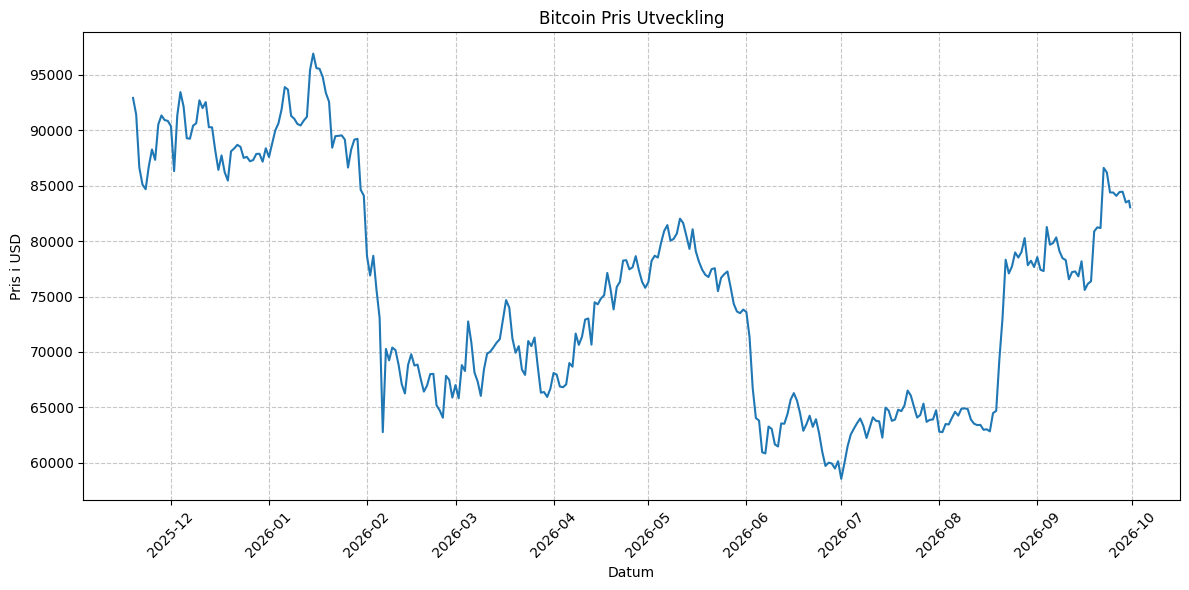

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Skapa linjediagrammet
plt.figure(figsize=(12, 6)) # Ställ in en bra figurstorlek
sns.lineplot(x='timestamp', y='price', data=df)
plt.title('Bitcoin Pris Utveckling') # Lägg till titel
plt.xlabel('Datum') # Lägg till x-axel etikett
plt.ylabel('Pris i USD') # Lägg till y-axel etikett
plt.grid(True, linestyle='--', alpha=0.7) # Lägg till ett rutnät för läsbarhet
plt.xticks(rotation=45) # Rotera datumetiketter om de överlappar
plt.tight_layout() # Justera layout för att förhindra att etiketter klipps av
plt.show() # Visa diagrammet

In [19]:
%%writefile README.md
# Bitcoin Data pipeline för AI/ML

## 🎯 Mål
Hämta hem bitcoin data och validera samt normalisera den. Även beräkning av medelvärden samt skicka ut en linjegaf.

## 🛠️ Metod
*   **Datahämtning**: Använder CoinGecko API
*   **Datahantering**: Sparar rådata i `JSON` och bearbetad data i `CSV` (`pandas`).
*   **Feature Engineering**: Beräknar `MA20`, `MA50` och volatilitet. Medelvärden, Detta för att kunna beräkna risk för investerare.
*   **Visualiserar datan med matplotlib**
*   **Normalisering**: Skalar data med `MinMaxScaler` (`sklearn`) inför ML/AI.
*   **Felhantering**: `try-except` för API-anrop och filåtgärder.

## 📊 Resultat
Två huvudfiler genereras:
*   `data/bitcoin_raw.json`: Rådata från API.
*   `data/bitcoin_processed.csv`: Normaliserad och bearbetad data, redo för ML/AI.
*   Skriver ut en linjegraf med Matplotlib för att kunna se trenden klart och tydligt.

## 📈 Analys
*   Ger en stabil grund för AI-utveckling.
*   Minimerar problem som ofta uppstår i ML-projekt.
*   Gör det lättare att träna modeller effektivt.

## 💡 Reflektion
Projektet visar integrationen av API, Pandas, OOP och ML-förberedelse framgångsrikt.

**Vad var svårt?**
*   Att hantera tidsseriedata och få rätt tidsstämplar och sortering.
*   Att beräkna glidande medelvärden och volatilitet, eftersom det skapar tomma värden i början.
*   Att balansera felhantering med att koden fortfarande är lätt att läsa.
*   Att designa klasserna så att de fungerar bra för både allmän och specifik Bitcoin-data.

**Vad skulle jag göra annorlunda?**
*   Detta projekt känns för avancerat en grundkurs.
*   Men i ett större projekt skulle jag kanske bryta ut koden i fler mindre delar (moduler) för att göra det mer organiserat.
*   Jag skulle också kunna lägga till ännu mer avancerade beräkningar eller fler visualiseringar.

## 🔗 GitHub-länk
https://github.com/Shorka84/Bitcoin_tracker

## ⚙️ Installation & Körning
1.  **Klona repositoryt**.
2.  **Installera bibliotek**: `pip install requests pandas scikit-learn`
3.  **Kör i anteckningsboken** sekventiellt i Google Colab eller Jupyter.

Overwriting README.md


In [14]:
%%writefile .gitignore
# Python-specifika filer
*.pyc
__pycache__/

# Virtuella miljöer
venv/
.venv/

# Jupyter/Colab-specifika filer
.ipynb_checkpoints/

# Datafiler genererade av projektet
data/
bitcoin_raw.json
bitcoin_processed.csv

# README-filen (om den genereras av notebooken)
README.md

# Temporära filer och loggar
*.log
*.tmp
*.bak

# Colab-specifika dolda kataloger
.config/

Writing .gitignore
